In [1]:
import torch
import matplotlib.pyplot as plt
from mask import ssdu_mask_subsample
from mri_utils import make_acc_mask
# ------------------------------------------------------------------------------------
# Setup: create a simple undersampled k-space mask (Ω)
# Simulates a 2D mask with random undersampling at ~30% acceleration
# ------------------------------------------------------------------------------------

B, Nx, Ny = 1, 64, 64
acceleration = 4  # 4x accel

torch.manual_seed(42)

# Random undersampling mask — in practice this would come from your acquisition
# m_omega = torch.rand(B, 1, Nx, Ny) < acceleration
m_omega = make_acc_mask(
    [Nx, Ny],
    acceleration,
    acs_lines=10,
    dim=1,
    device = 'cpu',
)
print(f"Ω mask shape:         {m_omega.shape}")
print(f"Ω acquired points:    {m_omega[0, 0].sum().item()} / {Nx * Ny}")

Ω mask shape:         torch.Size([1, 1, 64, 64])
Ω acquired points:    1472.0 / 4096


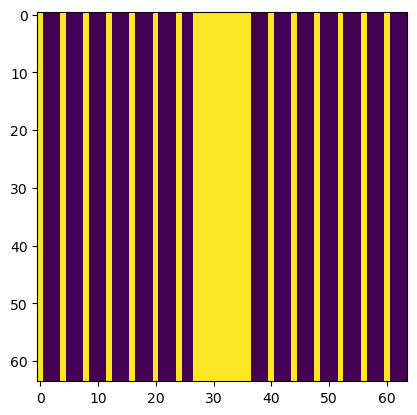

In [2]:
plt.imshow(m_omega.detach().cpu().numpy()[0,0])

In [10]:
m_omega = m_omega.bool()
m_lambda_rng, m_xi_rng = ssdu_mask_subsample(
    m_omega,
    rho=(0.4, 0.6),  # rho drawn uniformly from [0.4, 0.6] per batch element
    acs_size = 10,
    type="uniform_1D",
)

print(f"\n--- Random rho in [0.4, 0.6] ---")
for b in range(B):
    lam = m_lambda_rng[b, 0].sum().item()
    xi  = m_xi_rng[b, 0].sum().item()
    total = m_omega[b, 0].sum().item()
    print(f"  Batch {b}: Λ={lam}, Ξ={xi}, Ω={total}, rho≈{lam/total:.2f}")



--- Random rho in [0.4, 0.6] ---
  Batch 0: Λ=872, Ξ=700, Ω=1472, rho≈0.59


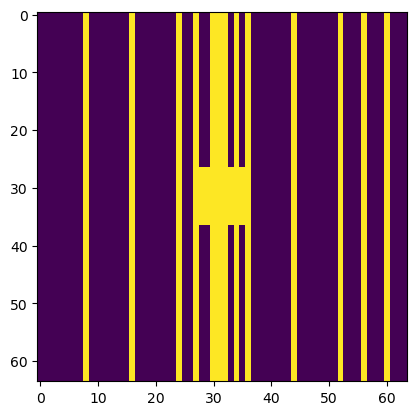

In [11]:
plt.imshow(m_lambda_rng.detach().cpu().numpy()[0,0])